# Predicting Personal Loan Acceptance using Customer Data
## Phase 1: Data Preparation & Visualisation

## Table of Contents
* [Introduction](#itr)
  + [Dataset Source](#Dataset-Source)
  + [Dataset Details](#Dataset-Details)
  + [Dataset Features](#Dataset-Features)
  + [Target Feature](#Target-Feature)
* [Goals and Objectives](#Goals-and-Objectives)
* [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
* [Data Exploration and Visualisation](#Data-Exploration-and-Visualisation)
* [Literature Review](#Literature-Review)
* [Summary and Conclusion](#Summary-and-Conclusion)
* [References](#References)



## Introduction <a id='itr'></a>

### Dataset Source

The dataset used for this analysis is publicly available on Kaggle, a popular data science platform, and the name of the dataset is “Bank Personal Loan Modelling”



### Dataset Details

<div style="text-align: justify">
The Bank Personal Loan Modelling dataset contains 5,000 observations and 14 features related to customer demographics, financial status, and banking behavior. Each row represents a unique customer, with attributes such as age, income, education level, average credit card spending, and whether they use services like online banking or credit cards. The main objective of this dataset is to predict whether a customer accepted a personal loan offer (Personal Loan), which serves as the target variable.
</div>

In [1]:
# Suppressing the warnings
import warnings
warnings.filterwarnings('ignore')

# Importing the neccesary libraries used for the analysis for the Phase 1
import pandas as pd
from tabulate import tabulate
import seaborn as sns
import matplotlib.pyplot as plt

# Setting the display options for pandas to show all columns in the dataframe output
pd.set_option('display.max_columns', None)

<div style="text-align: justify">
The above code uses the warnings module to stop warning messages from showing up. This is done to keep the output neat and easy to read. Then, it imports two main Python libraries: pandas, which is used to work with data in tables, and numpy, which is used for numbers and calculations. Lastly, the code sets an option in pandas so that when a table (DataFrame) is printed, all the columns will be shown instead of just a few.
</div>

In [2]:
# Creating a variable to store the name of the dataset file for easy reference and potential reuse
df_name = "../data/raw/Bank_Personal_Loan_Modelling.csv"

In [3]:
# Importing the dataset of bank personal loan modelling data from the CSV file into a pandas DataFrame
bank_personal_loan_dataset = pd.read_csv(df_name)

In [4]:
# Displaying randomly 10 rows from the dataset
bank_personal_loan_dataset.sample(10, random_state=999)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
3581,3582,28,4,33,91330,3,1/00,2,0,0,0,0,0,1
3035,3036,50,24,31,95054,1,0/30,3,0,0,0,0,0,0
2455,2456,34,8,164,94720,4,7/40,3,0,1,0,0,1,0
3014,3015,60,34,40,91311,1,2/50,3,166,0,0,0,1,0
3114,3115,29,4,55,90024,4,2/00,2,0,0,1,0,1,0
2673,2674,54,30,88,92647,4,1/00,2,122,0,0,0,1,0
767,768,64,39,38,92024,1,1/10,3,108,0,0,0,0,0
2919,2920,35,10,64,94542,3,2/30,1,0,0,0,1,1,1
3575,3576,63,38,15,94305,4,0/60,2,83,0,0,0,0,0
1253,1254,57,33,45,92346,4,1/50,1,204,0,0,0,1,0


### Dataset Features

The table below outlines the features in our dataset, with descriptions adapted from the original Kaggle data source.

In [5]:
# Creating a variable table to display the data Features details in a tabular format
table = [['Name', 'Data Type', 'Units', 'Description'],
         ['ID', 'Numeric', 'NA', 'Unique customer ID'],
         ['Age', 'Numeric', 'Years', 'Customer\'s age in completed years'],
         ['Experience', 'Numeric', 'Years', 'Years of professional experience'],
         ['Income', 'Numeric', 'USD per year', 'Annual income of the customer'],
         ['ZIP Code', 'Nominal categorical', 'NA', 'Residential ZIP code of the customer'],
         ['Family', 'Numeric', 'Persons', 'Family size of the customer'],
         ['CCAvg', 'Numeric', 'USD per year', 'Average credit card spending per year'],
         ['Education', 'Ordinal categorical', 'NA', 'Educational level of each customer (1 = Undergrad, 2 = Graduate, 3 = Advanced)'],
         ['Personal Loan', 'Binary', 'Yes/No', 'Accepted personal loan in last campaign (1 = Yes, 0 = No)'],
         ['Securities Account', 'Binary', 'Yes/No', 'Has a securities account with the bank (1 = Yes, 0 = No)'],
         ['CD Account', 'Binary', 'Yes/No', 'Has a certificate of deposit account (1 = Yes, 0 = No)'],
         ['Online', 'Binary', 'Yes/No', 'Uses internet banking (1 = Yes, 0 = No)'],
         ['CreditCard', 'Binary', 'Yes/No', 'Uses credit card issued by UniversalBank (1 = Yes, 0 = No)']]

# Printing the table 
print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))

╒════════════════════╤═════════════════════╤══════════════╤════════════════════════════════════════════════════════════════════════════════╕
│ Name               │ Data Type           │ Units        │ Description                                                                    │
╞════════════════════╪═════════════════════╪══════════════╪════════════════════════════════════════════════════════════════════════════════╡
│ ID                 │ Numeric             │ NA           │ Unique customer ID                                                             │
├────────────────────┼─────────────────────┼──────────────┼────────────────────────────────────────────────────────────────────────────────┤
│ Age                │ Numeric             │ Years        │ Customer's age in completed years                                              │
├────────────────────┼─────────────────────┼──────────────┼────────────────────────────────────────────────────────────────────────────────┤
│ Experience 

### Target Feature

<div style="text-align: justify">
The target feature in this dataset is Personal Loan, which indicates whether a customer accepted a personal loan offer made by the bank during a previous marketing campaign or not. It is a binary variable, where:

* 1 means the customer accepted the loan offer, and
* 0 means the customer did not accept the offer.

This feature is what we aim to predict using the other customer-related information in the dataset. By understanding what influences loan acceptance, the bank can better target future offers and improve campaign success rates.
</div>

## Goals and Objectives

<div style="text-align: justify">
The main goal of this project is to develop a machine learning model that accurately predicts whether a customer will accept a personal loan offer. Specifically, we aim to:
 
*   Recognize the key elements that affect loan approval.
*   Examine trends in consumer demographics and financial practices that affect loan choices.
*   Create a predictive model to help the bank better target its marketing campaigns.
*   Enhance the client experience by enabling tailored financial offers and estimating the likelihood of loan acceptance.
 
</div>


## Data Cleaning and Preprocessing

In this section, we describe the data cleaning and preprocessing steps undertaken for the analysis for Phase 1

### Data Cleaning Steps

*   Dropping the  irrelevant features which are not used for the analysis
*   Checking and renaming the column names for better readibility
*   Checking for Unique value count for each features
*   Checking for the missing values in the dataset
*   Removing all the observations which has missing values in the dataset
*   Checking for the Duplicates Observations in the dataset

Let's start by checking the features in the dataset

In [6]:
# Displaying the column names of the bank personal loan dataset
bank_personal_loan_dataset.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='str')

In [7]:
# Converting the column names to an appropriate case and also removing any white spaces in the column names
bank_personal_loan_dataset.columns = bank_personal_loan_dataset.columns.str.strip()

bank_personal_loan_dataset.rename(columns={
    'ID': 'Customer_ID',
    'Income': 'Annual_Income',
    'ZIP Code': 'ZIP_Code',
    'Family': 'Family_Size',
    'CCAvg': 'CreditCard_Spending',
    'Education': 'Education_Level',
    'Personal Loan': 'Personal_Loan',
    'Securities Account': 'Securities_Account',
    'CD Account': 'CD_Account',
    'Online': 'Online_Banking',
    'CreditCard': 'Uses_CreditCard'
}, inplace=True)

# Displaying the first 5 rows of the dataset after the remaining the columns
bank_personal_loan_dataset.sample(5, random_state=999)

,Customer_ID,Age,Experience,Annual_Income,ZIP_Code,Family_Size,CreditCard_Spending,Education_Level,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online_Banking,Uses_CreditCard
3581,3582,28,4,33,91330,3,1/00,2,0,0,0,0,0,1
3035,3036,50,24,31,95054,1,0/30,3,0,0,0,0,0,0
2455,2456,34,8,164,94720,4,7/40,3,0,1,0,0,1,0
3014,3015,60,34,40,91311,1,2/50,3,166,0,0,0,1,0
3114,3115,29,4,55,90024,4,2/00,2,0,0,1,0,1,0


In [8]:
# Checking the datatypes of the columns
bank_personal_loan_dataset.dtypes

Customer_ID            int64
Age                    int64
Experience             int64
Annual_Income          int64
ZIP_Code               int64
Family_Size            int64
CreditCard_Spending      str
Education_Level        int64
Mortgage               int64
Personal_Loan          int64
Securities_Account     int64
CD_Account             int64
Online_Banking         int64
Uses_CreditCard        int64
dtype: object

Checking for the datatypes for each features so that if any of the datatypes are not in proper type then we can convert it into to proper datatypes.
But in our case all datatypes are in proper type and don't need any changes for our analysis.

In [9]:
# Checking the shape of the bank_personal_loan_dataset
print(f"Shape of the bank personal loan dataset = {bank_personal_loan_dataset.shape} \n")

Shape of the bank personal loan dataset = (5000, 14) 



In [10]:
# Checking for unique values for each columnz in the dataset
bank_personal_loan_dataset.nunique()

Customer_ID            5000
Age                      45
Experience               47
Annual_Income           162
ZIP_Code                467
Family_Size               4
CreditCard_Spending     108
Education_Level           3
Mortgage                347
Personal_Loan             2
Securities_Account        2
CD_Account                2
Online_Banking            2
Uses_CreditCard           2
dtype: int64

<div style="text-align: justify">
To determine the kind of data in each feature, we looked at the number of unique values in each column. This assisted us in determining which columns are numeric, which require encoding, and whether any should be eliminated.

The output demonstrates that the majority of features have several distinct values, indicating that they are appropriate for modeling.  Certain columns, such as Securities_Account, CD_Account, Online_Banking, and Uses_CreditCard, are binary features because they only have two distinct values.  Since Education_Level and Family_Size are categorical, one-hot encoding will be required for Phase 2. All things considered, the dataset contains a suitable blend of binary, categorical, and numeric features for creating a classification model.
</div>

In [11]:
# Inspecting the unique values in CreditCard_Spending column
bank_personal_loan_dataset['CreditCard_Spending'].unique()[:20]

<StringArray>
['1/60', '1/50', '1/00', '2/70', '0/40', '0/30', '0/60', '8/90', '2/40',
 '0/10', '3/80', '2/50', '2/00', '4/70', '8/10', '0/50', '0/90', '1/20',
 '0/70', '3/90']
Length: 20, dtype: str

In [12]:
# Converting the 'CreditCard_Spending' column to numeric values
bank_personal_loan_dataset['CreditCard_Spending'] = bank_personal_loan_dataset['CreditCard_Spending'].str.replace('/', '.', regex=False).astype(float)

After checking the unique values in the CreditCard_Spending column, we found they were in an incorrect format (e.g., '1/60' instead of 1.60). To fix this, we replaced the '/' with '.' using `str.replace()` and then converted the column to numeric type using `.astype(float)` so that the data is usable for analysis and modeling.

In [13]:
# Viewing the summary statistics of the dataset to understand the distribution of the data
bank_personal_loan_dataset.describe()

,Customer_ID,Age,Experience,Annual_Income,ZIP_Code,Family_Size,CreditCard_Spending,Education_Level,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online_Banking,Uses_CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [14]:
# Dropping the negative values in Experience column
bank_personal_loan_dataset = bank_personal_loan_dataset[bank_personal_loan_dataset['Experience'] >= 0]

<div style="text-align: justify">
After viewing the summary we found that the experience column min were in negative so we dropped the negative values from the experience feature because experience cannot be negative and also personal loan would highly imbalance and would impact our model.
</div>

In [15]:
# Checking for the missing or null values in the entire dataset
print(f"\nNumber of missing values for each column:")
print(bank_personal_loan_dataset.isnull().sum())


Number of missing values for each column:
Customer_ID            0
Age                    0
Experience             0
Annual_Income          0
ZIP_Code               0
Family_Size            0
CreditCard_Spending    0
Education_Level        0
Mortgage               0
Personal_Loan          0
Securities_Account     0
CD_Account             0
Online_Banking         0
Uses_CreditCard        0
dtype: int64


In [16]:
bank_personal_loan_dataset.duplicated().sum()
print(f"\nNumber of duplicate rows in the dataset: {bank_personal_loan_dataset.duplicated().sum()} \n")


Number of duplicate rows in the dataset: 0 



After checking we found that there were no missing, null or duplicates values in any of the observation.

In [17]:
# Displaying the quick summary of the dataset using the info() method
bank_personal_loan_dataset.info()

<class 'pandas.DataFrame'>
Index: 4948 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          4948 non-null   int64  
 1   Age                  4948 non-null   int64  
 2   Experience           4948 non-null   int64  
 3   Annual_Income        4948 non-null   int64  
 4   ZIP_Code             4948 non-null   int64  
 5   Family_Size          4948 non-null   int64  
 6   CreditCard_Spending  4948 non-null   float64
 7   Education_Level      4948 non-null   int64  
 8   Mortgage             4948 non-null   int64  
 9   Personal_Loan        4948 non-null   int64  
 10  Securities_Account   4948 non-null   int64  
 11  CD_Account           4948 non-null   int64  
 12  Online_Banking       4948 non-null   int64  
 13  Uses_CreditCard      4948 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 579.8 KB


## Data Exploration and Visualisation

After performing the preprocessing step now our dataset is considered to be clean and we can proceed with visualising and explore the data.

### One-Variable Visualisation

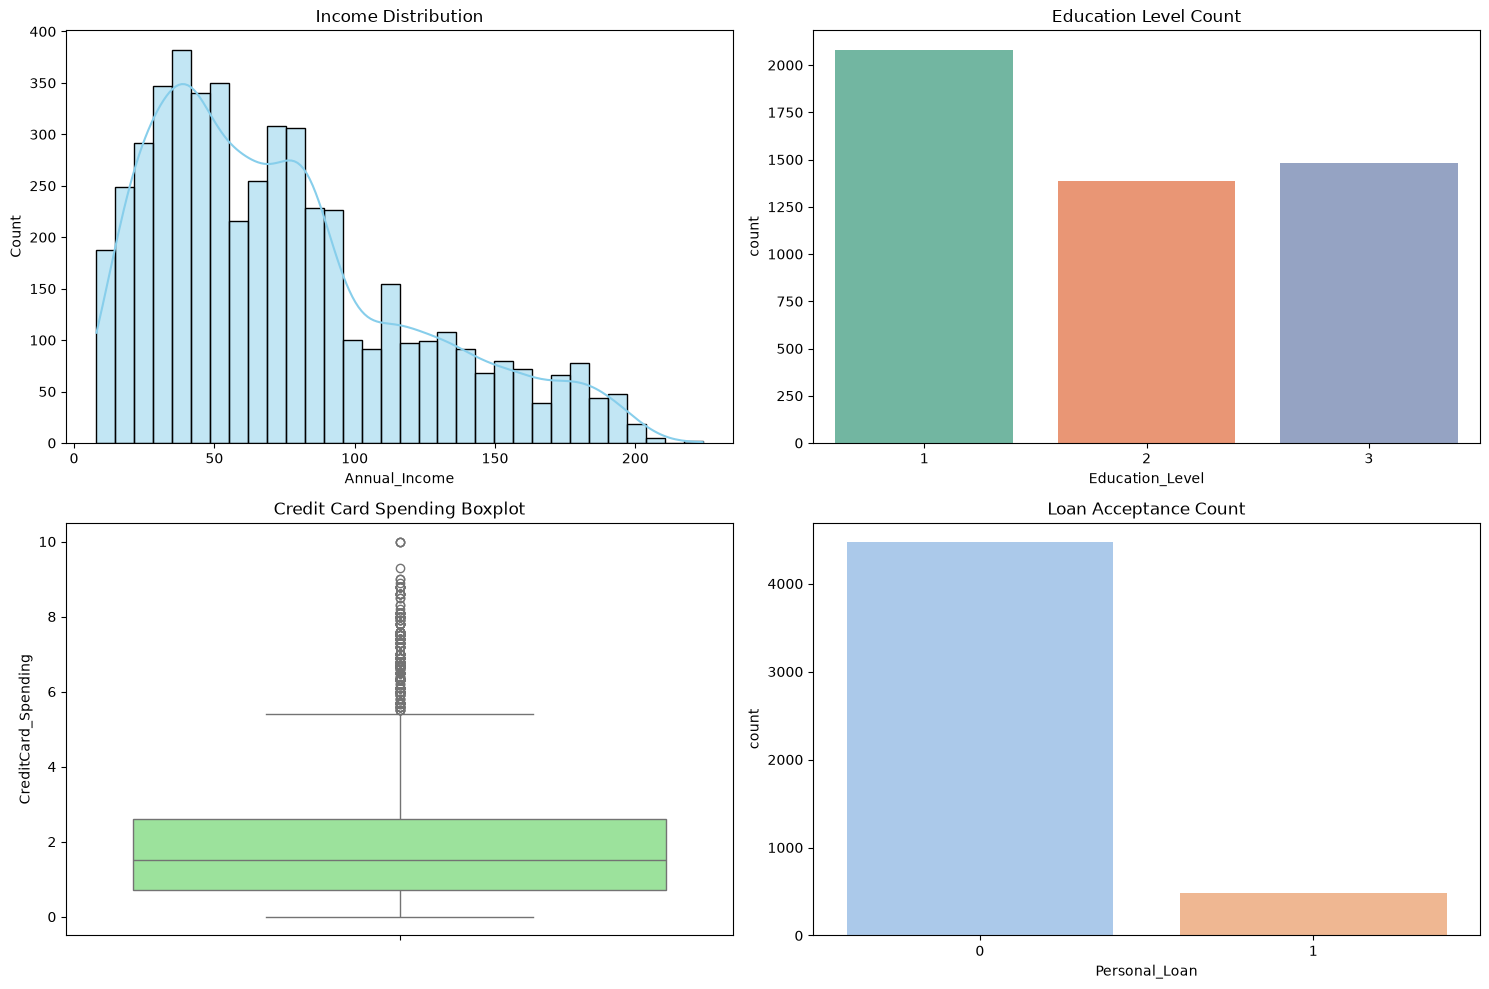

In [18]:
# Displaying all the plots in a single figure
plt.figure(figsize=(15, 10))

# Plot 1: Income distribution
plt.subplot(2, 2, 1)
sns.histplot(bank_personal_loan_dataset['Annual_Income'], kde=True, color='skyblue')
plt.title('Income Distribution')

# Plot 2: Education Level distribution
plt.subplot(2, 2, 2)
sns.countplot(x='Education_Level', data=bank_personal_loan_dataset, palette='Set2')
plt.title('Education Level Count')

# Plot 3: Credit Card Spending distribution
plt.subplot(2, 2, 3)
sns.boxplot(y='CreditCard_Spending', data=bank_personal_loan_dataset, color='lightgreen')
plt.title('Credit Card Spending Boxplot')

# Plot 4: Personal Loan acceptance count
plt.subplot(2, 2, 4)
sns.countplot(x='Personal_Loan', data=bank_personal_loan_dataset, palette='pastel')
plt.title('Loan Acceptance Count')

plt.tight_layout()
plt.show()



<div style="text-align: justify">

1. Income Distribution:
The income distribution shows most customers earn within a lower range of 20 to 80 units, while a few earning significantly higher incomes at above 150.

2. Education Level Count:
The education level distribution shows that higher education levels could be related to customer behavior towards loans. Level 1 has the highest number of individuals, followed by levels 3 and 2.

3. Credit Card Spending Boxplot:
Credit card spending has a wide range, with a few customers spending a lot more than others. Most spending is between 0 and 4 units, with a few people spending much more.

4. Loan Acceptance Count:
Personal Loan acceptance is imbalanced, with more customers rejecting the loans(shown by bar 0) than accepting ( shown by bar 1).
</div>

### Two-Variable Visualisation

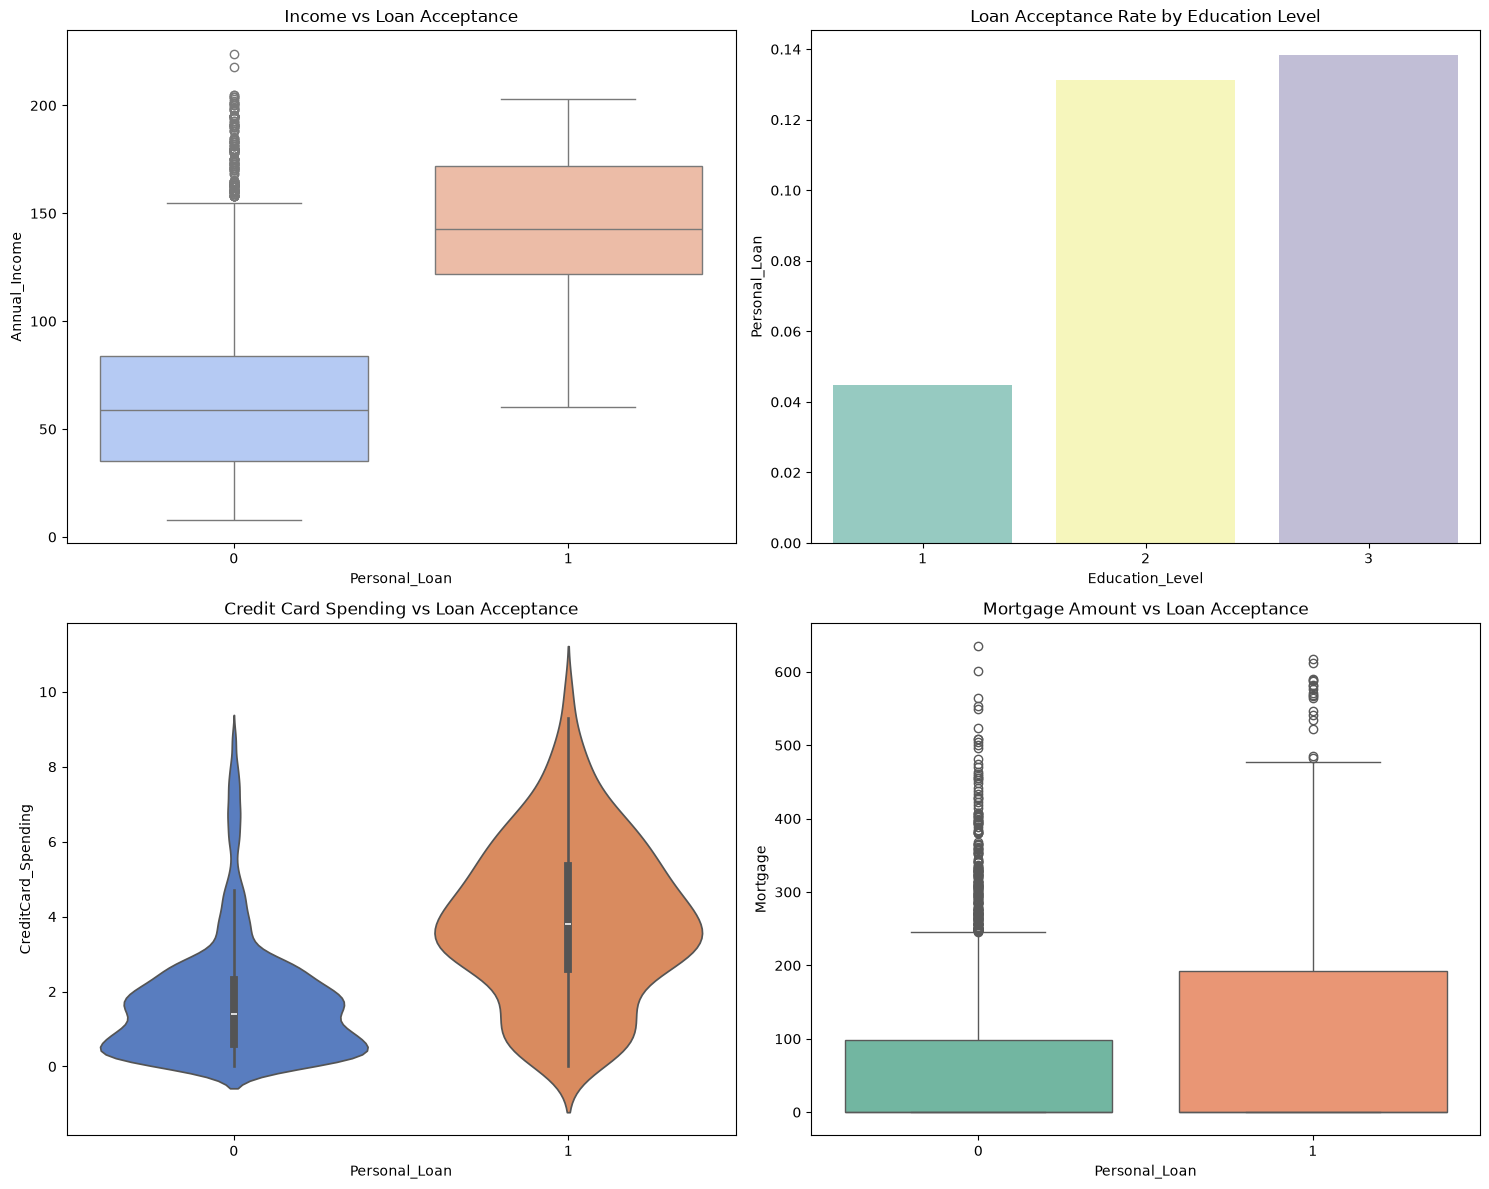

In [19]:
# Displaying all the plots in a single figure
plt.figure(figsize=(15, 12))

# Plot 1: Income vs. Loan Acceptance
plt.subplot(2, 2, 1)
sns.boxplot(x='Personal_Loan', y='Annual_Income', data=bank_personal_loan_dataset, palette='coolwarm')
plt.title('Income vs Loan Acceptance')

# Plot 2: Education Level vs. Loan Acceptance
plt.subplot(2, 2, 2)
sns.barplot(x='Education_Level', y='Personal_Loan', data=bank_personal_loan_dataset, ci=None, palette='Set3')
plt.title('Loan Acceptance Rate by Education Level')

# Plot 3: Credit Card Spending vs. Loan Acceptance
plt.subplot(2, 2, 3)
sns.violinplot(x='Personal_Loan', y='CreditCard_Spending', data=bank_personal_loan_dataset, palette='muted')
plt.title('Credit Card Spending vs Loan Acceptance')

# Plot 4: Mortgage vs. Loan Acceptance
plt.subplot(2, 2, 4)
sns.boxplot(x='Personal_Loan', y='Mortgage', data=bank_personal_loan_dataset, palette='Set2')
plt.title('Mortgage Amount vs Loan Acceptance')

plt.tight_layout()
plt.show()


<div style="text-align: justify">

1. Income vs Loan Acceptance: The boxplot compares annual income of people who were accepted for a loan and those who were not. Customers who accepted loans generally have higher annual incomes compared to those who did not (Personal_Loan = 1).

2. Loan Acceptance Rate by Education Level: The bar chart shows the loan acceptance rate based on education levels. Higher education levels(2 and 3) seem to slightly increase the probability of accepting a personal loan.

3. Credit Card Spending vs Loan Acceptance: The violin plot shows that the customers who got the loan tend to spend more on their credit cards.

4. Mortgage Amount vs Loan Acceptance: The boxplot shows that , people with larger mortgage amounts tend to accept loans more often.
</div>

### Three-Variable Visualisation

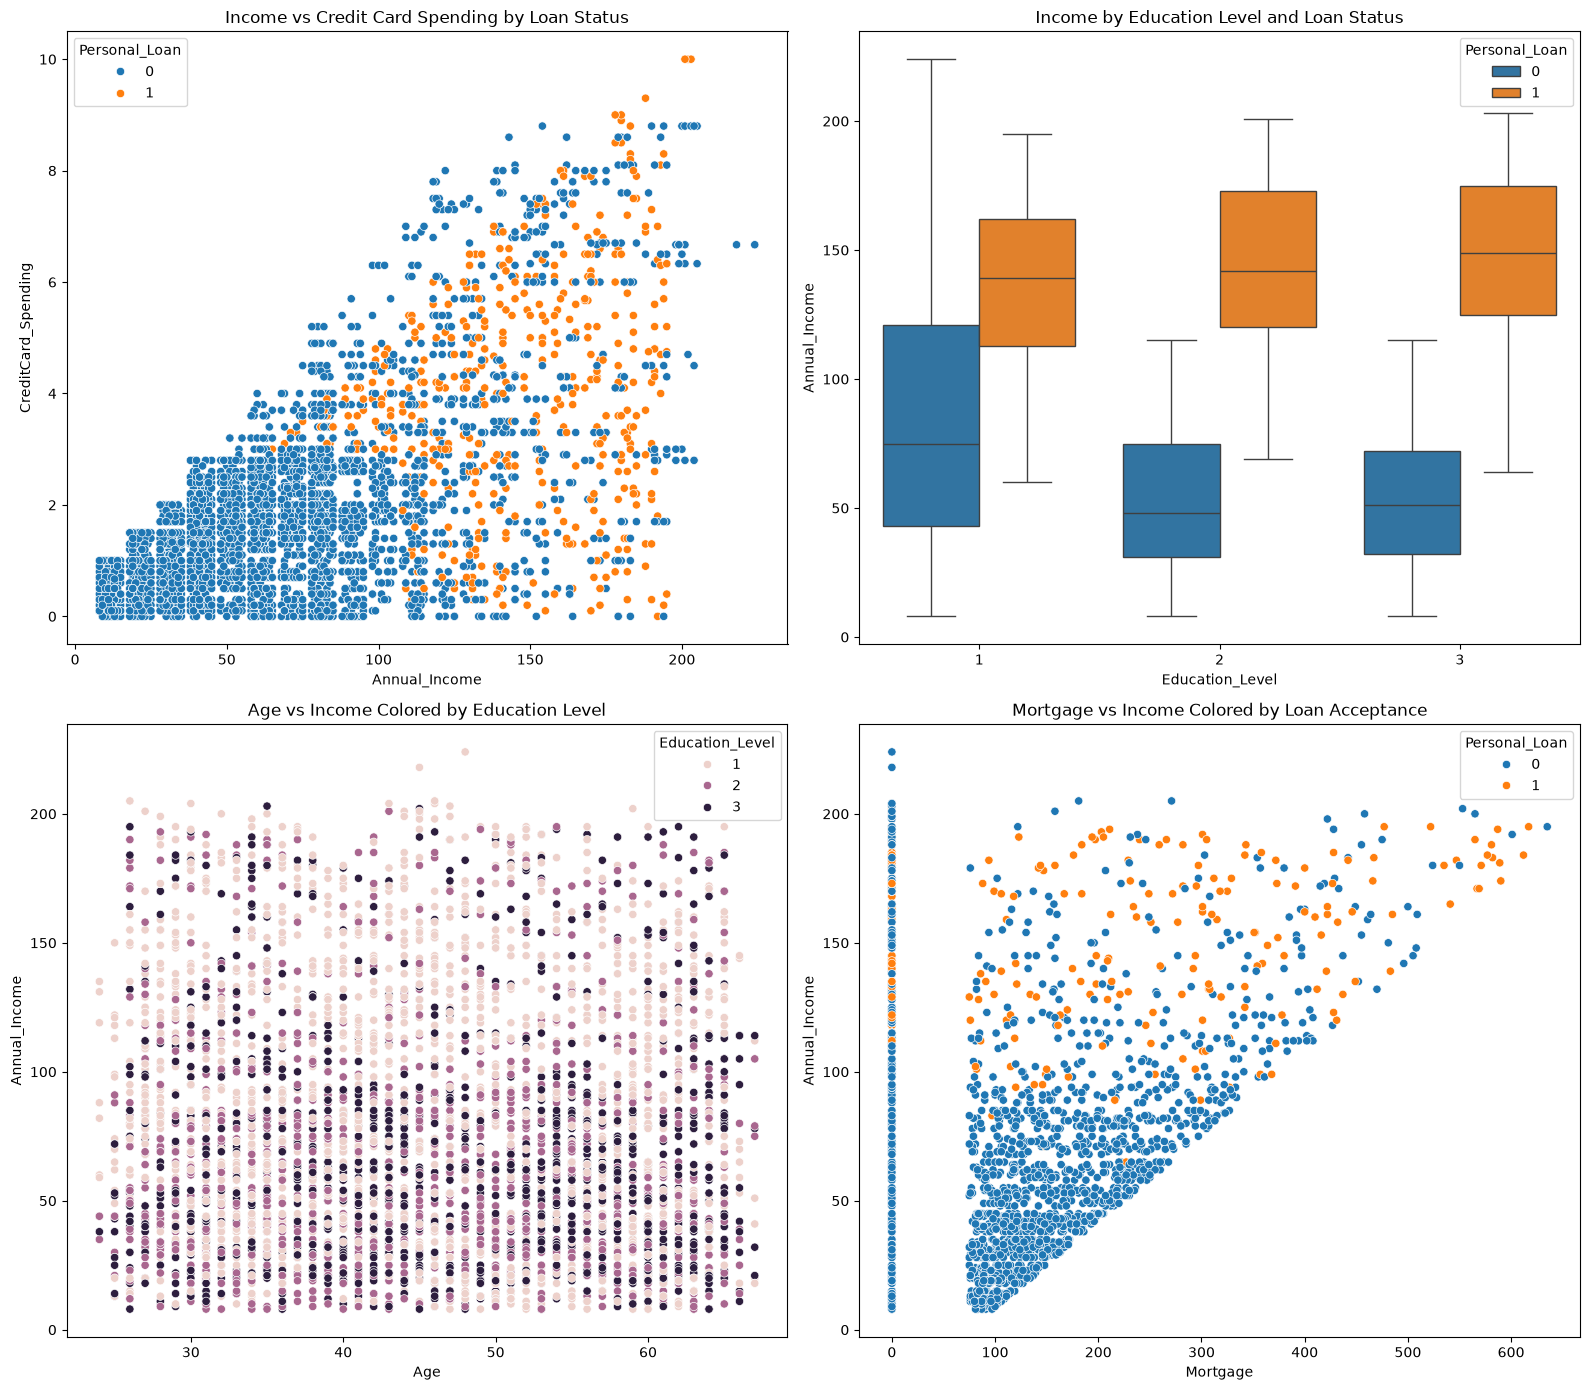

In [20]:
# Displaying all the plots in a single figure
plt.figure(figsize=(16, 14))

# Plot 1: Income vs CreditCard Spending by Loan Status
plt.subplot(2, 2, 1)
sns.scatterplot(x='Annual_Income', y='CreditCard_Spending', hue='Personal_Loan', data=bank_personal_loan_dataset)
plt.title('Income vs Credit Card Spending by Loan Status')

# Plot 2: Education vs Income by Loan Status
plt.subplot(2, 2, 2)
sns.boxplot(x='Education_Level', y='Annual_Income', hue='Personal_Loan', data=bank_personal_loan_dataset)
plt.title('Income by Education Level and Loan Status')

# Plot 3: Age vs Income by Education Level
plt.subplot(2, 2, 3)
sns.scatterplot(x='Age', y='Annual_Income', hue='Education_Level', data=bank_personal_loan_dataset)
plt.title('Age vs Income Colored by Education Level')

# Plot 4: Mortgage vs Income by Loan Status
plt.subplot(2, 2, 4)
sns.scatterplot(x='Mortgage', y='Annual_Income', hue='Personal_Loan', data=bank_personal_loan_dataset)
plt.title('Mortgage vs Income Colored by Loan Acceptance')

plt.tight_layout()
plt.show()


In [21]:
# Saving the cleaned dataset to a new CSV file for future use or analysis
bank_personal_loan_dataset.to_csv("../data/processed/Phase1_cleaned.csv", index=False)

<div style="text-align: justify">

1. Income vs Credit Card Spending by Loan Status: The scatter plot illustrates the relationship between credit card spending and income. Individuals with higher incomes typically spend more on credit cards. The majority of loan recipients (orange dots) have high incomes and high spending levels.

2. Income by Education Level and Loan Status: Incomes for various educational levels are compared in this boxplot. People who received a loan tend to  make more money than those who did not in each group.

3. Age vs Income Colored by Education Level: The scatter plot helps illustrates how age affects income. The color of each dot represents the individual's educational attainment. Regardless of age, those with more education (darker colors) typically earn more money.

4. Mortgage vs Income Colored by Loan Acceptance: In this plot, people's mortgage amounts are contrasted with their income and who was loaned money. Fewer low-income applicants are approved, while the majority of loan approvals (orange dots) go to those with higher incomes and larger mortgage amounts.
</div>

## Literature Review

<div style="text-align: justify">
In recent years use of machine learning in predicting personal loan acceptance has gained significant traction. Mostly it’s due to the potential of improved decision making, minimizing risks, and enhancing the marketing strategies in banking sector. With the increase in digitisation and consumer data availability, Banks are moving toward a data driven model approach to determine loan eligibility and optimize campaign targeting.
The efficiency of machine learning models in loan approval systems is shown in several scholarly publications and peer-reviewed journal articles. Haque and Hassan (2024) used a variety of machine learning models, such as AdaBoost, Random Forest, SVM, and Logistic Regression, on a dataset comprising more than 148,000 entries in a study that was published in the American Journal of Industrial and Business Management. Their research shows the effectiveness of ensemble methods, especially AdaBoost, which attained a remarkable 99.99% accuracy rate, making it a powerful tool for binary classification tasks such as personal loan prediction.
Fati In his research, published in the Journal of Hunan University Natural Sciences, Fati (2023) examined the use of logistic regression for loan approval and discovered that, out of a few models, it was the most accurate and comprehensible. The International Journal of Novel Research and Development (IJNRD) published an evaluation of algorithms like Random Forest, Naive Bayes, and Logistic Regression in 2024. Bhanu and Prasad concluded that Random Forest had the highest accuracy because of its resilience to overfitting and capacity to handle mixed-type data. In a related study, Bhavani (2024) provided proof in favour of this conclusion by demonstrating how, when used properly, models like Random Forest and Naive Bayes greatly decreased the amount of manual labour required to screen loan applications.
The notion that tree-based and ensemble models are becoming more successful in financial analysis and credit scoring is also supported by other peer-reviewed studies, such as those that were published in the Gazi University Journal of Science and Finance Research Letters.
A lot of conference papers offer helpful insights in addition to journal articles. For instance, one useful method for using machine learning to forecast loan eligibility was presented in the IEEE conference paper Bank Loan Prediction System Using Machine Learning Models (2024). This study's primary goal was to streamline the loan approval procedure and lessen the need for manual review of repetitive tasks.
The 7th North American International Conference on Industrial Engineering and Operations Management (IEOM) made another major contribution by comparing models like SVM, Decision Trees, and Logistic Regression. Their findings demonstrated that, despite its simplicity, Logistic Regression performed better than more intricate models because of its consistent and transparent decision boundaries. These findings means that, in addition to model complexity, model selection should also consider the dataset's quality and structure.

*   In her presentation at the International Conference on Data Science and Engineering (ICDSE) in 2024, Guang Xuan Chen highlighted the value of ensemble approaches. Her research revealed that, when used on a loan eligibility dataset, AdaBoost outperformed other popular models in terms of accuracy. This backs up previous assertions regarding the potency of boosting algorithms, especially when there is a class imbalance.

*   A paper titled Loan Prediction System Using Machine Learning was presented at the ITM Web of Conferences (ICACC 2022). It suggested a comprehensive pipeline for automating loan approval. To decrease manual screening and increase model-driven decisions, the study focused on practical deployment, demonstrating how demographic, financial, and behavioural attributes could be processed.

*   Academic theses and student project reports (like the UMass Dartmouth paper and Clara Baptista's master's thesis), are not peer-reviewed, they provide insightful practical experiences with applying machine learning models to banking applications.

Overall, the most popular and successful algorithms across all the studies we looked at were SVM, Random Forest, AdaBoost, and Logistic Regression. While Random Forest and AdaBoost exhibit superior performance metrics, particularly with bigger or more complex datasets, Logistic Regression stands out for its interpretability and dependability.
</div>

### Journals

<p style="text-align: justify;"><em>

[1] Haque, A., & Hassan, M. M. (2024). Bank Loan Prediction Using Machine Learning Techniques. American Journal of Industrial and Business Management, 14(12). https://doi.org/10.4236/ajibm.2024.1412085

[2] Suliman Mohamed Fati, & Suliman Mohamed Fati. (2021). Machine Learning-Based Prediction Model for Loan Status Approval. Journal of Hunan University Natural Sciences, 48(10). https://jonuns.com/index.php/journal/article/view/783

[3] Bhanu, S., & Siva Prasad, Y. (2024). Loan Eligibility Prediction Using Machine Learning. NTERNATIONAL JOURNAL of NOVEL RESEARCH and DEVELOPMENT, 9(7). https://www.ijnrd.org/papers/IJNRD2407179.pdf

[4] Bhavani, G. (2024). Loan Approval Prediction Using Machine Learning. International Journal of Research Publication and Reviews Journal Homepage: Www.ijrpr.com, 5(1). https://ijrpr.com/uploads/V5ISSUE1/IJRPR21516.pdf

[5] Özkurt, C. (2024). Enhancing Financial Decision-Making: Predictive Modeling for Personal Loan Eligibility with Gradient Boosting, XGBoost, and AdaBoost. Information Technology in Economics and Business. https://doi.org/10.69882/adba.iteb.2024072

[6] Zhu, X., Chu, Q., Song, X., Hu, P., & Peng, L. (2023). Explainable prediction of loan default based on machine learning models. Data Science and Management, 6(3). https://doi.org/10.1016/j.dsm.2023.04.003

[7] Sinap, V. (2024, April). A Comparative Study of Loan Approval Prediction Using Machine Learning  Methods. ResearchGate. https://www.researchgate.net/publication/381415188_A_Comparative_Study_of_Loan_Approval_Prediction_Using_Machine_Learning_Methods

[8] Ma, Z., & Wu, Q. (2023, August 10). Research on the Prediction Method for Personal Loan Default Based on Two-Layer Stacking Ensemble Learning Model. Www.atlantis-Press.com; Atlantis Press. https://doi.org/10.2991/978-94-6463-198-2_113

[9] Alexandra, C., Martins, S., Baptista, C., De Almeida, A., Associada, P., & Nunes, L. (2023). Predictive Modeling of Financed Amount of Personal Loans in the context of Outbound Marketing. https://repositorio.iscte-iul.pt/bitstream/10071/30446/1/master_clara_carvalho_baptista.pdf

[10] Singh, S. (2024). Predictive Modeling for Personal Loan Acceptance in Banking. https://bpb-us-w2.wpmucdn.com/sites.umassd.edu/dist/0/1467/files/2024/05/Project_Paper_Report.pdf
</em></p>

### Conference Papers

<p style="text-align: justify;"><em>

[1] Hussain, M. Z., Ejaz, S., Ezza Batool, Hasan, M. Z., Mustafa, M., Khalid, A., Hussain, U., Khan, Z., Javaid, A., Ashraf, M. F., Awan, R., & Yaqub, M. A. (2024). Bank Loan Prediction System Using Machine Learning Models. Bank Loan Prediction System Using Machine Learning Models. https://doi.org/10.1109/i2ct61223.2024.10543786

[2] Al Mamun, M., Farjana, A., & Mamun, M. (2022, June). Predicting Bank Loan Eligibility Using Machine Learning Models and Comparison Analysis. In 7th North American International Conference on Industrial Engineering and Operations Management, https://doi.org/10.46254/NA07.20220328.

[3] Chen, G. (2024). Predicting Loan Eligibility Approval Using Machine Learning Algorithms. Proceedings of the 1st International Conference on Data Science and Engineering, 512–517. https://doi.org/10.5220/0012828200004547

[4] Shinde, A., Patil, Y., Kotian, I., Shinde, A., & Gulwani, R. (2022). Loan Prediction System Using Machine Learning. ITM Web of Conferences, 44, 03019. https://doi.org/10.1051/itmconf/20224403019
</em></p>

## Summary and Conclusions

<div style="text-align: justify">

In the first phase of this project, we performed steps for understanding and preparing the data for modelling. We started by checking the dataset carefully, making sure there were no missing values or innocent entries that could affect our analysis.

Thankfully, the dataset was pretty clean and well- structured, which allowed us to move quickly into exploring the data after removing and renaming some columns.
Through visualisation, we were able to pick up on some interesting patterns. For example , we noticed that the customers with higher incomes, higher education levels , and larger mortgages were more likely to accept the personal loans. These insights are valuable because they play a big role in loan decesions.
 
The thing that stood out for us was the imbalance in our target variable of Personal Loan – many more customers declined loans than accepted them. This is something we will need to address carefully in Phase 2 when building predictive models using resampling techniques or adjusting model parameters.
 
Overall, the first phase gave us a strong understanding of the dataset and the relationships between different features. We now have a clean , ready-to-use dataset and sense of what to expect and move into the next phase of the project, where we will start building machine learning models to predict personal loan acceptance.
</div>

## References

<p style="text-align: justify;"><em>

[1] Rafiee, A. (2024). Bank personal loan. Www.kaggle.com. https://www.kaggle.com/datasets/ahmadrafiee/bank-personal-loan

[2] akmand. (2024, July 22). statististics_tutorials/Phase1_Report_Sample.ipynb at main · akmand/statististics_tutorials. GitHub. https://github.com/akmand/statististics_tutorials/blob/main/Phase1_Report_Sample.ipynb

[3] Pandas. (2024). DataFrame — pandas 2.2.3 documentation. Pydata.org. https://pandas.pydata.org/docs/reference/frame.html

[4] Waskom, M. (2024). seaborn.scatterplot — seaborn 0.11.1 documentation. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.scatterplot.

[5] Waskom, M. (2024). seaborn.boxplot — seaborn 0.11.1 documentation. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.boxplot.html

[6] Waskom, M. (2024). seaborn.violinplot — seaborn 0.11.1 documentation. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.violinplot.html

[7] Waskom, M. (2024). seaborn.barplot — seaborn 0.11.1 documentation. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.barplot.html

[8] Waskom, M. (2024). seaborn.countplot — seaborn 0.11.1 documentation. Pydata.org. https://seaborn.pydata.org/generated/seaborn.countplot.html

[9] Waskom, M. (2024). seaborn.histplot — seaborn 0.11.1 documentation. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.histplot.html
</em></p>

Sinap, V. (2024, April). A Comparative Study of Loan Approval Prediction Using Machine Learning  Methods. ResearchGate. https://www.researchgate.net/publication/381415188_A_Comparative_Study_of_Loan_Approval_Prediction_Using_Machine_Learning_Methods


***